# plotting

TODO: Add a description here.

- reorder the cells 
- create a description on how to instuments a normal micropython.py script to log memory info over time to a file 
- explain how to run this notebook to plot the logged memory info data


In [2]:
# Enabling the `widget` backend.
# This requires the module ipympl (a.k.a jupyter-matplotlib ) that should already be installed
# ipympl can be install from PyPi
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np

In [3]:
%store -r log_text
from micropython_magic.memoryinfo import MemoryInfoList

mi_list = MemoryInfoList(show_free=False)
print(
    f"Loaded and parsed {len(mi_list.parse_log(log_text))} memory_info records from the log file"
)

no stored variable or alias log_text


NameError: name 'log_text' is not defined

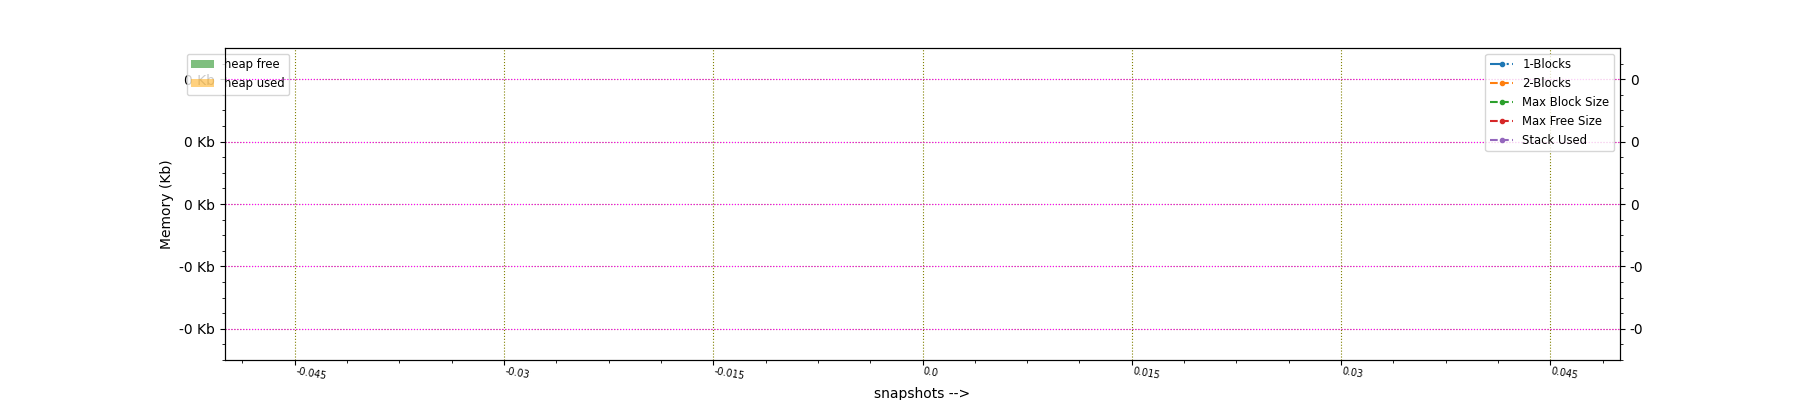

In [ ]:
# clean up previous plot - save memory
# plt.close()

fig1 = mi_list.plot(
    free=True,
    # stack_total=True,
    one_blocks=True,
    two_blocks=True,
    max_block_size=True,
    max_free_size=True,
    stack_used=True,
    size=(18, 4),
)

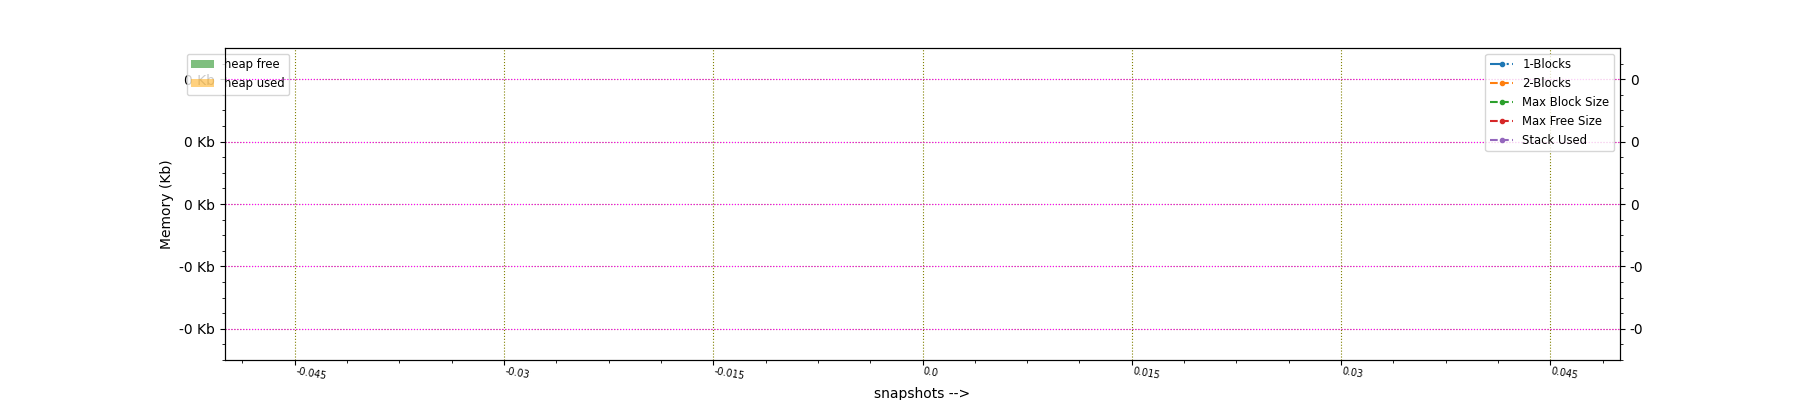

In [ ]:
plt.show(fig1)

You can also call `display` on `fig.canvas` to display the interactive plot anywhere in the notebooke


Hover Over :

- https://stackoverflow.com/questions/7908636/how-to-add-hovering-annotations-to-a-plot/47166787#47166787
- https://stackoverflow.com/questions/55891285/how-to-make-labels-appear-when-hovering-over-a-point-in-multiple-axis/55892690#55892690
-


In [4]:
# %%micropython
from micropython import mem_info
from time import gmtime, localtime, ticks_ms, time_ns


def timestamp():
    return time_ns() + ((ticks_ms() % 1_000_000) * 1_000)


def log_mem(id="", verbose=0):
    print(f"\n*** Memory info {id} ***")
    # add time to the log
    # print(f"time:{localtime()}")
    print(f"time:{timestamp()}")
    if verbose:
        mem_info(1)
    else:
        mem_info()
    print("***********************\n")

In [5]:
# %%micropython
import time
import random

log_mem("before")
for n in range(100):
    block = bytearray(500 + random.randint(0, 1000))
    log_mem(f"step {n}")
    time.sleep_ms(10)

log_mem("after")

*** Memory info before ***
time:1953189690000
stack: 992 out of 15360
GC: total: 112000, used: 51920, free: 60080, max new split: 53248
 No. of 1-blocks: 42, 2-blocks: 15, max blk sz: 3073, max free sz: 3279
***********************
*** Memory info step 0 ***
time:1953208383000
stack: 992 out of 15360
GC: total: 112000, used: 53504, free: 58496, max new split: 53248
 No. of 1-blocks: 57, 2-blocks: 17, max blk sz: 3073, max free sz: 3202
***********************
*** Memory info step 1 ***
time:1953238349000
stack: 992 out of 15360
GC: total: 112000, used: 55280, free: 56720, max new split: 53248
 No. of 1-blocks: 72, 2-blocks: 19, max blk sz: 3073, max free sz: 3110
***********************
*** Memory info step 2 ***
time:1953268282000
stack: 992 out of 15360
GC: total: 112000, used: 56384, free: 55616, max new split: 53248
 No. of 1-blocks: 87, 2-blocks: 21, max blk sz: 3073, max free sz: 3049
***********************
*** Memory info step 3 ***
time:1953298310000
stack: 992 out of 15360
GC

In [6]:
output = _
# log_text = __
log_text = list(output)

In [7]:
from micropython_magic.memoryinfo import MemoryInfoList

mi_list = MemoryInfoList(show_free=False)
print(
    f"Loaded and parsed {len(mi_list.parse_log(log_text))} memory_info records from the log file"
)

Loaded and parsed 102 memory_info records from the log file


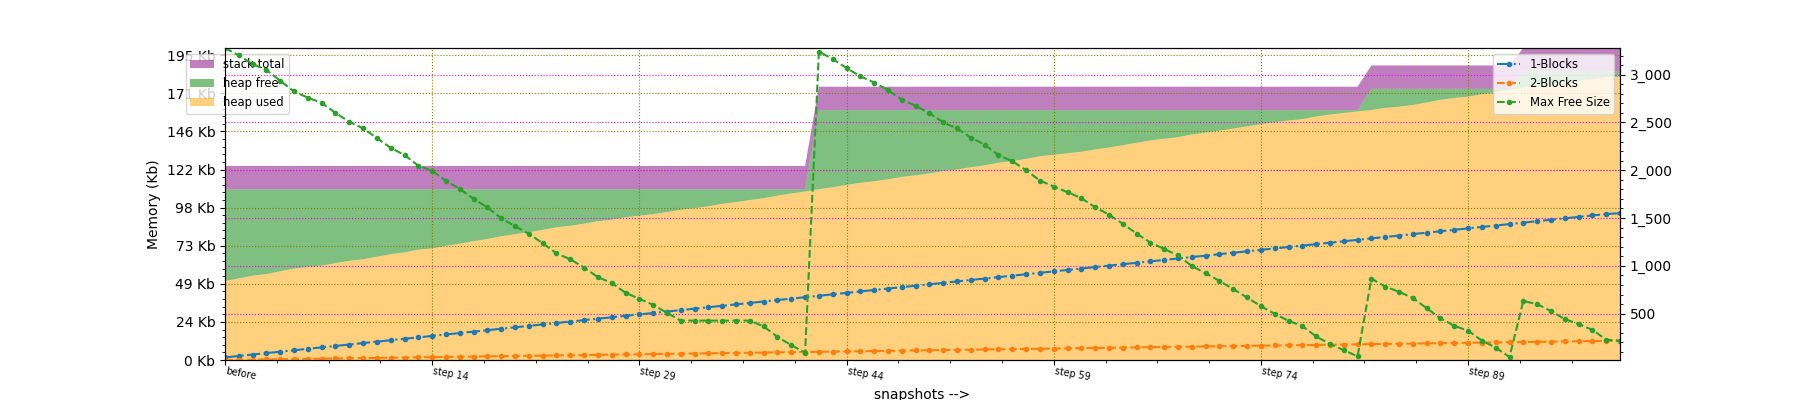

In [8]:
p2 = mi_list.plot(
    free=True,
    stack_total=True,
    one_blocks=True,
    two_blocks=True,
    # max_block_size=True,
    max_free_size=True,
    # stack_used=True,
    size=(18, 4),
    time_axis=False,
)

Plot with many text-labels on the x-axis
Labels are plotted sparly - and additional labels are added when zooming in
